### **Статистический анализ вибрационных сигналов методами математической статистики с целью прогнозирования отказов оборудования**
В работе были проведены исследования
путём построения гистограмм относительных частот, построения вариационных
и интервальных вариационных рядов, построены эмпирические функции
распределения, проведены расчёты статистик, таких как выборочное среднее,
выборочная дисперсия, СКО, коэффициент вариации и другие. Вычислены
точечные оценки параметров методами максимального правдоподобия,
моментов и байесовским подходом, исследованы их свойства. Построены
доверительные интервалы, проверены статистические гипотезы с
использованием критериев Харке–Бера, Манна–Уитни и отношения
правдоподобия. Проведена идентификация распределений с помощью критерия
согласия Пирсона и метода анаморфоз, а также подведены итоги по всем трём
разделам курсовой работы.

В рамках данного параграфа будут рассмотрены исходные данные на тему
курсовой работы «анализ вибрационных сигналов подшипников качения».
Исходный набор данных CWRU Bearing Dataset содержит 4 класса сигналов и
121 846 отсчётов для каждого класса:
+ Normal — вибросигнал исправного подшипника без искусственных
дефектов.
+ IR_14 — вибросигнал подшипника с дефектом внутренней обоймы
диаметром 14 мил (0,36 мм).
+ OR_14 — вибросигнал подшипника с дефектом внешней обоймы
диаметром 14 мил.
+ B_14 — вибросигнал подшипника с дефектом тела качения диаметром 14
мил.

Каждый сигнал представляет собой одномерный временной ряд —
последовательность измерений ускорения вибрации (g), записанных с частотой
дискретизации 12 000 Гц.

# РАЗДЕЛ 1: ПРЕДВАРИТЕЛЬНЫЙ СТАТИСТИЧЕСКИЙ АНАЛИЗ

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import os

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [21]:
import random

def generate_random_color():
    """Генерация случайного яркого цвета в формате hex."""
    r = random.randint(50, 220)
    g = random.randint(50, 220)
    b = random.randint(50, 220)
    return f'#{r:02x}{g:02x}{b:02x}'

COLORS = {
    'original': generate_random_color(),
    'grid': '#E8E8E8',
    1: generate_random_color(),
    2: generate_random_color(),
    3: generate_random_color(),
    4: generate_random_color(),
    5: generate_random_color(),
    6: generate_random_color(),
    7: generate_random_color(),
    8: generate_random_color(),
    9: generate_random_color(),
    'IR_14': generate_random_color(),
    'OR_14': generate_random_color(),
    'B_14': generate_random_color(),
    'Normal': generate_random_color(),
}

In [8]:
import os

repo_name = "CWRU_Bearing_NumPy"
if not os.path.exists(repo_name):
    os.system(f'git clone https://github.com/srigas/CWRU_Bearing_NumPy.git {repo_name}')

os.chdir(repo_name)

DATA_PATH = "Data/1797 RPM"
files = {
    'Normal': '1797_Normal.npz',
    'IR_14': '1797_IR_14_DE12.npz',
    'OR_14': '1797_OR@6_14_DE12.npz',
    'B_14': '1797_B_14_DE12.npz',
}

data = {}
for name, fname in files.items():
    npz = np.load(os.path.join(DATA_PATH, fname))
    data[name] = npz['DE'].flatten()

Cloning into 'CWRU_Bearing_NumPy'...
Updating files: 100% (163/163), done.


In [11]:
# выравнивание длины
min_len = min(len(s) for s in data.values())
for name in data:
    data[name] = data[name][:min_len]

classes = ['Normal', 'IR_14', 'OR_14', 'B_14']
n = min_len
fs = 12000  # частота дискретизации

print("Таблица 1.1 — Структура исследуемых данных")
print("-" * 60)
print(f"{'Столбец':<10} {'Тип данных':<12} {'Описание'}")
print("-" * 60)
print(f"{'DE':<10} {'float64':<12} Ускорение вибрации (g)")
print("-" * 60)
print(f"Размер выборки: n = {n} отсчётов ({n/fs:.2f} сек)")

for name in classes:
    print(f"{name}:")
    print(f"  Первые 5:    {data[name][:5].round(4)}")
    print(f"  Последние 5: {data[name][-5:].round(4)}")

Таблица 1.1 — Структура исследуемых данных
------------------------------------------------------------
Столбец    Тип данных   Описание
------------------------------------------------------------
DE         float64      Ускорение вибрации (g)
------------------------------------------------------------
Размер выборки: n = 121846 отсчётов (10.15 сек)
Normal:
  Первые 5:    [ 0.0532  0.0887  0.0997  0.0586 -0.0046]
  Последние 5: [ 0.0713  0.1079  0.111   0.0724 -0.0121]
IR_14:
  Первые 5:    [-0.2238 -0.2095  0.3453  0.1589 -0.2066]
  Последние 5: [-0.0138  0.1311  0.0478 -0.0767  0.0031]
OR_14:
  Первые 5:    [ 0.0023 -0.1049  0.082   0.094  -0.1601]
  Последние 5: [-0.1088 -0.0747 -0.1124 -0.0853 -0.0263]
B_14:
  Первые 5:    [-0.4678  0.179   0.4813 -0.1582 -0.3268]
  Последние 5: [ 0.2311  0.0489 -0.3377 -0.1691  0.1779]


In [13]:
def sturges_bins(n):
    """Количество интервалов по формуле Стерджесса"""
    return int(1 + 3.322 * np.log10(n))

k = sturges_bins(n)
print(f"Формула Стерджесса: k = 1 + 3.322·lg({n}) = {k} интервалов")

# Интервальный вариационный ряд для Normal
signal = data['Normal']
hist, edges = np.histogram(signal, bins=k)
rel_freq = hist / n

print("\nТаблица 1.2 — Интервальный вариационный ряд (Normal, фрагмент)")
print("-" * 55)
print(f"{'№':<3} {'Границы интервала':<22} {'nᵢ':<8} {'wᵢ':<8}")
print("-" * 55)
for i in [0, 1, k//2-1, k//2, k-2, k-1]:
    print(f"{i+1:<3} [{edges[i]:+.3f}; {edges[i+1]:+.3f})  {hist[i]:<8} {rel_freq[i]:.4f}")
print("-" * 55)

Формула Стерджесса: k = 1 + 3.322·lg(121846) = 17 интервалов

Таблица 1.2 — Интервальный вариационный ряд (Normal, фрагмент)
-------------------------------------------------------
№   Границы интервала      nᵢ       wᵢ      
-------------------------------------------------------
1   [-0.287; -0.251)  5        0.0000
2   [-0.251; -0.216)  43       0.0004
8   [-0.040; -0.005)  20839    0.1710
9   [-0.005; +0.030)  22657    0.1859
16  [+0.241; +0.276)  33       0.0003
17  [+0.276; +0.311)  2        0.0000
-------------------------------------------------------


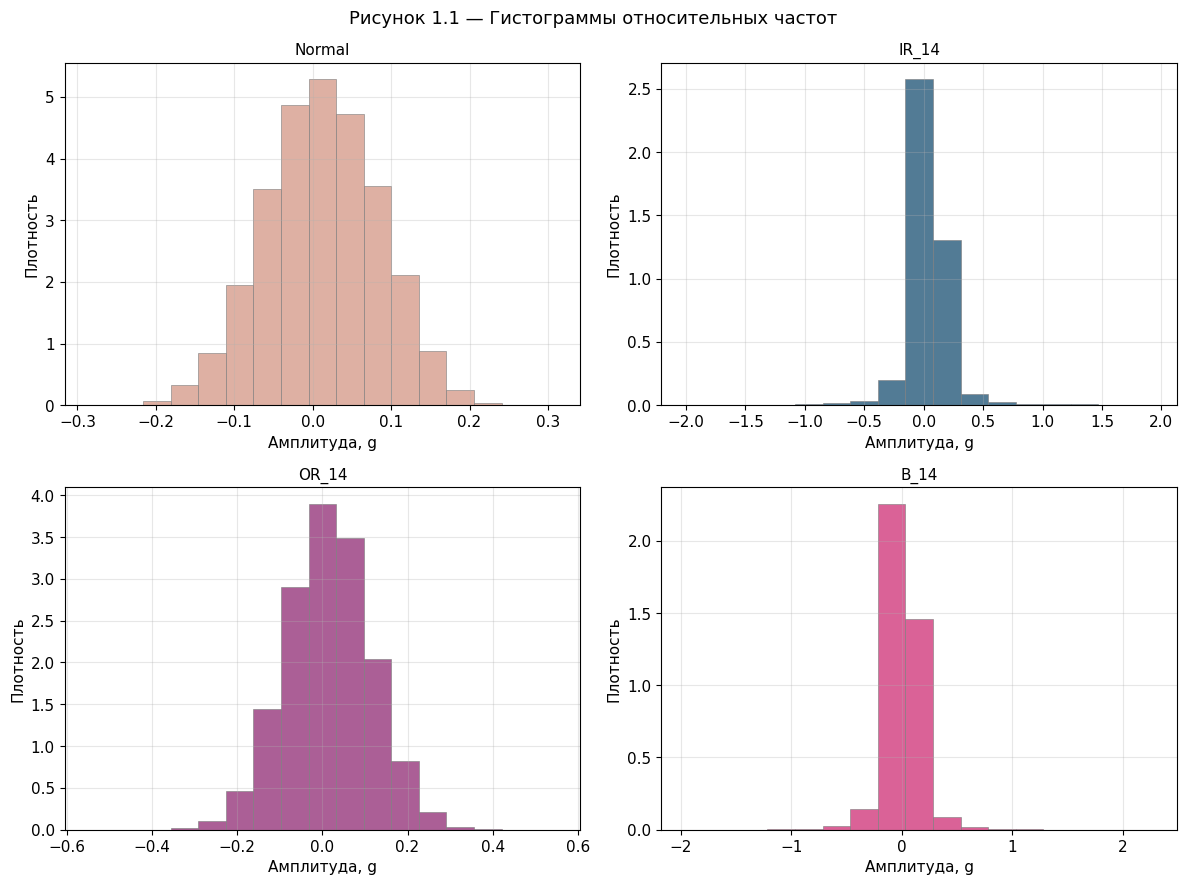

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Рисунок 1.1 — Гистограммы относительных частот', fontsize=13)

for idx, name in enumerate(classes):
    ax = axes[idx // 2, idx % 2]
    ax.hist(data[name], bins=k, density=True, color=COLORS[name],
            edgecolor='gray', linewidth=0.5, alpha=0.85)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Амплитуда, g')
    ax.set_ylabel('Плотность')

plt.tight_layout()
plt.show()

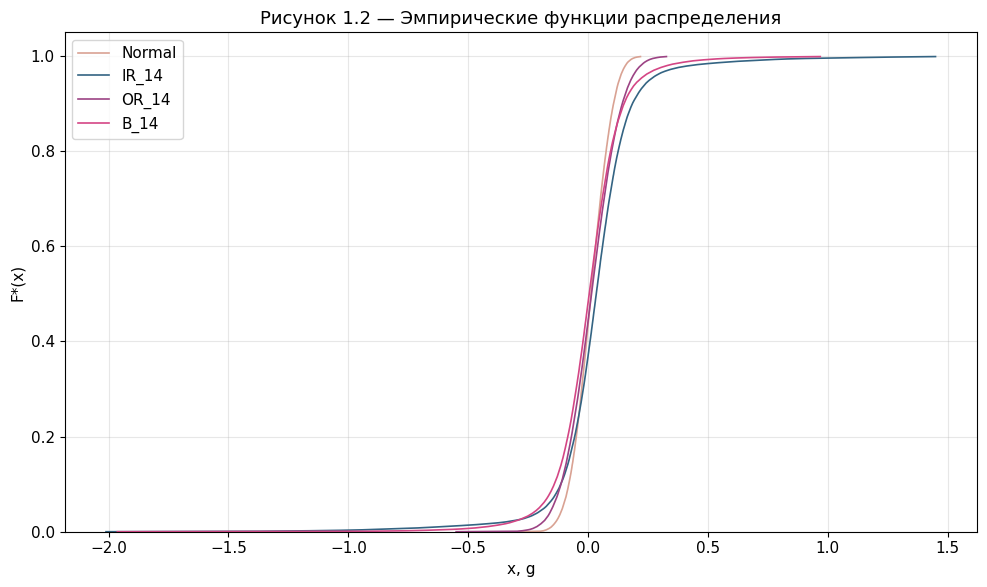

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title('Рисунок 1.2 — Эмпирические функции распределения', fontsize=13)

for name in classes:
    sorted_s = np.sort(data[name])
    ecdf = np.arange(1, n + 1) / n
    step = max(1, n // 1000)  # прореживание для визуализации
    ax.plot(sorted_s[::step], ecdf[::step], color=COLORS[name], lw=1.2, label=name)

ax.set_xlabel('x, g')
ax.set_ylabel('F*(x)')
ax.legend()
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

In [27]:
def calc_stats(signal):
    """Расчёт выборочных характеристик"""
    n = len(signal)
    mean = np.mean(signal)
    var = np.var(signal, ddof=1)  # несмещённая
    std = np.std(signal, ddof=1)
    cv = (std / abs(mean)) * 100 if mean != 0 else np.inf
    return {'n': n, 'x̄': mean, 'S²': var, 'S': std, 'CV%': cv}

results = []
for name in classes:
    st = calc_stats(data[name])
    st['Класс'] = name
    results.append(st)

df_stats = pd.DataFrame(results)[['Класс', 'n', 'x̄', 'S²', 'S', 'CV%']]
print("Таблица 1.3 — Выборочные характеристики вибросигналов")
print(df_stats.to_string(index=False))

# Отношение СКО к норме
print("\nОтношение СКО к нормальному состоянию:")
rms_normal = df_stats[df_stats['Класс'] == 'Normal']['S'].values[0]
for _, row in df_stats.iterrows():
    ratio = row['S'] / rms_normal
    print(f"  {row['Класс']}: {ratio:.2f}x")

Таблица 1.3 — Выборочные характеристики вибросигналов
 Класс      n       x̄       S²        S         CV%
Normal 121846 0.012265 0.005165 0.071871  585.998664
 IR_14 121846 0.034433 0.037952 0.194812  565.765954
 OR_14 121846 0.014375 0.009930 0.099648  693.180979
  B_14 121846 0.004688 0.023300 0.152642 3256.127059

Отношение СКО к нормальному состоянию:
  Normal: 1.00x
  IR_14: 2.71x
  OR_14: 1.39x
  B_14: 2.12x


In [26]:
def point_estimates(signal):
    """Точечные оценки параметров нормального распределения"""
    n = len(signal)
    x_bar = np.mean(signal)

    # 1. ММП (Maximum Likelihood)
    mu_mle = x_bar
    sigma2_mle = np.var(signal, ddof=0)  # смещённая

    # 2. Метод моментов
    m1 = np.mean(signal)
    m2 = np.mean(signal**2)
    mu_mm = m1
    sigma2_mm = m2 - m1**2

    # 3. Байесовская оценка (неинформативный априор)
    mu_0, kappa_0, alpha_0, beta_0 = 0, 0.001, 0.001, 0.001
    kappa_n = kappa_0 + n
    mu_bayes = (kappa_0 * mu_0 + n * x_bar) / kappa_n
    alpha_n = alpha_0 + n / 2
    beta_n = beta_0 + 0.5 * np.sum((signal - x_bar)**2)
    sigma2_bayes = beta_n / (alpha_n - 1) if alpha_n > 1 else beta_n / alpha_n

    # Несмещённая оценка дисперсии
    sigma2_unbiased = np.var(signal, ddof=1)

    return {
        'μ̂_ММП': mu_mle, 'μ̂_ММ': mu_mm, 'μ̂_Bayes': mu_bayes,
        'σ̂²_ММП': sigma2_mle, 'σ̂²_ММ': sigma2_mm,
        'σ̂²_Bayes': sigma2_bayes, 'S²': sigma2_unbiased
    }

estimates = []
for name in classes:
    est = point_estimates(data[name])
    est['Класс'] = name
    estimates.append(est)

df_est = pd.DataFrame(estimates)
cols = ['Класс', 'μ̂_ММП', 'μ̂_ММ', 'μ̂_Bayes', 'σ̂²_ММП', 'σ̂²_ММ', 'σ̂²_Bayes', 'S²']
df_est = df_est[cols]

print("Таблица 1.4 — Точечные оценки параметров распределения")
print(df_est.to_string(index=False, float_format=lambda x: f'{x:.6f}'))

Таблица 1.4 — Точечные оценки параметров распределения
 Класс   μ̂_ММП    μ̂_ММ  μ̂_Bayes  σ̂²_ММП   σ̂²_ММ  σ̂²_Bayes       S²
Normal 0.012265 0.012265  0.012265 0.005165 0.005165   0.005165 0.005165
 IR_14 0.034433 0.034433  0.034433 0.037951 0.037951   0.037952 0.037952
 OR_14 0.014375 0.014375  0.014375 0.009930 0.009930   0.009930 0.009930
  B_14 0.004688 0.004688  0.004688 0.023299 0.023299   0.023300 0.023300


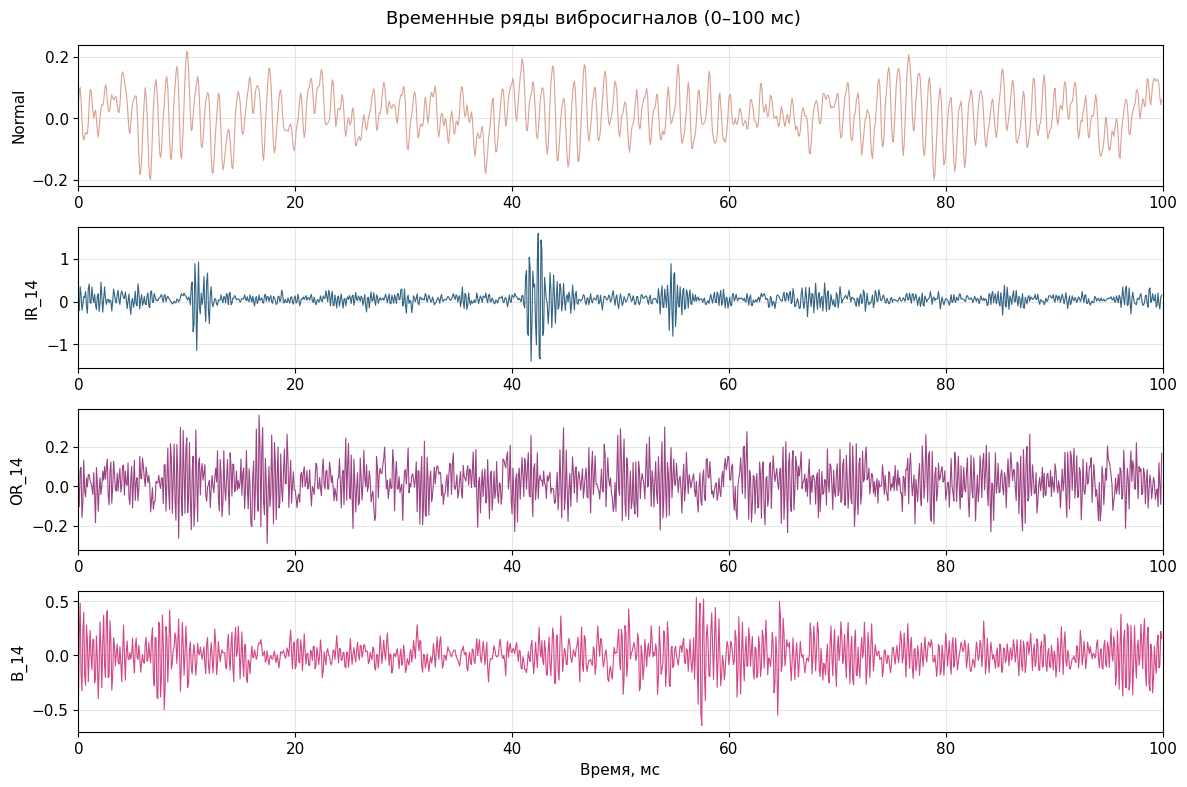

In [28]:
fig, axes = plt.subplots(4, 1, figsize=(12, 8))
fig.suptitle('Временные ряды вибросигналов (0–100 мс)', fontsize=13)

samples = 1200  # 0.1 сек при 12 кГц
t = np.arange(samples) / fs * 1000  # в мс

for idx, name in enumerate(classes):
    axes[idx].plot(t, data[name][:samples], color=COLORS[name], lw=0.8)
    axes[idx].set_ylabel(name)
    axes[idx].set_xlim([0, 100])

axes[-1].set_xlabel('Время, мс')
plt.tight_layout()
plt.show()

In [32]:
print("=" * 60)
print("РЕЗУЛЬТАТЫ РАЗДЕЛА 1")
print("=" * 60)
print(f"Объём выборки: n = {n} отсчётов")
print(f"Число интервалов по Стерджессу: k = {k}")
print(f"Диагностический признак — превышение СКО над нормой:")
for name in ['IR_14', 'OR_14', 'B_14']:
    rms = df_stats[df_stats['Класс'] == name]['S'].values[0]
    print(f"  {name}: СКО = {rms:.4f} ({rms/rms_normal:.1f}x от нормы)")
print("=" * 60)

РЕЗУЛЬТАТЫ РАЗДЕЛА 1
Объём выборки: n = 121846 отсчётов
Число интервалов по Стерджессу: k = 17
Диагностический признак — превышение СКО над нормой:
  IR_14: СКО = 0.1948 (2.7x от нормы)
  OR_14: СКО = 0.0996 (1.4x от нормы)
  B_14: СКО = 0.1526 (2.1x от нормы)


# РАЗДЕЛ 2: СТАТИСТИЧЕСКИЕ ОЦЕНКИ И ПРОВЕРКА ГИПОТЕЗ

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import gaussian_kde

classes = ['Normal', 'IR_14', 'OR_14', 'B_14']
alpha = 0.05  # уровень значимости
gamma = 0.95  # надёжность

In [35]:
def point_estimates(signal):
    """Точечные оценки: медиана, мода, среднее, дисперсия, СКО"""
    n = len(signal)
    # Медиана: Me = x_(n/2) для упорядоченной выборки
    median = np.median(signal)
    # Мода через KDE: Mo = argmax f(x)
    kde = gaussian_kde(signal)
    x_grid = np.linspace(signal.min(), signal.max(), 1000)
    mode = x_grid[np.argmax(kde(x_grid))]
    # Математическое ожидание: x̄ = (1/n) Σxᵢ
    mean = np.mean(signal)
    # Дисперсия (несмещённая): S² = (1/(n-1)) Σ(xᵢ - x̄)²
    var = np.var(signal, ddof=1)
    # СКО: S = √S²
    std = np.std(signal, ddof=1)
    return {'Me': median, 'Mo': mode, 'x̄': mean, 'S²': var, 'S': std}

results_21 = []
for name in classes:
    est = point_estimates(data[name])
    est['Класс'] = name
    results_21.append(est)

df_21 = pd.DataFrame(results_21)[['Класс', 'Me', 'Mo', 'x̄', 'S²', 'S']]
print("Таблица 2.1 — Точечные оценки параметров распределения")
print(df_21.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

Таблица 2.1 — Точечные оценки параметров распределения
 Класс     Me     Mo     x̄     S²      S
Normal 0.0121 0.0096 0.0123 0.0052 0.0719
 IR_14 0.0339 0.0309 0.0344 0.0380 0.1948
 OR_14 0.0142 0.0105 0.0144 0.0099 0.0996
  B_14 0.0045 0.0023 0.0047 0.0233 0.1526


In [39]:
def confidence_intervals(signal, gamma=0.95):
    """Доверительные интервалы для μ, σ², σ, Me"""
    n = len(signal)
    alpha = 1 - gamma
    x_bar = np.mean(signal)
    s2 = np.var(signal, ddof=1)
    s = np.sqrt(s2)
    # ДИ для μ: x̄ ± t_(1-α/2, n-1) * S/√n
    t_crit = stats.t.ppf(1 - alpha/2, n - 1)
    ci_mu = (x_bar - t_crit * s / np.sqrt(n),
             x_bar + t_crit * s / np.sqrt(n))
    # ДИ для σ²: ((n-1)S²/χ²_(1-α/2), (n-1)S²/χ²_(α/2))
    chi2_low = stats.chi2.ppf(alpha/2, n - 1)
    chi2_high = stats.chi2.ppf(1 - alpha/2, n - 1)
    ci_var = ((n - 1) * s2 / chi2_high,
              (n - 1) * s2 / chi2_low)
    # ДИ для σ: √(ДИ для σ²)
    ci_std = (np.sqrt(ci_var[0]), np.sqrt(ci_var[1]))
    # ДИ для медианы (непараметрический)
    sorted_signal = np.sort(signal)
    z = stats.norm.ppf(1 - alpha/2)
    j = int(n/2 - z * np.sqrt(n)/2)
    k = int(n/2 + z * np.sqrt(n)/2)
    ci_me = (sorted_signal[max(0, j)], sorted_signal[min(n-1, k)])
    return {'μ': ci_mu, 'σ²': ci_var, 'σ': ci_std, 'Me': ci_me}

results_22 = []
for name in classes:
    ci = confidence_intervals(data[name], gamma)
    results_22.append({
        'Класс': name,
        'ДИ для μ': f"({ci['μ'][0]:.4f}; {ci['μ'][1]:.4f})",
        'ДИ для σ²': f"({ci['σ²'][0]:.5f}; {ci['σ²'][1]:.5f})",
        'ДИ для σ': f"({ci['σ'][0]:.4f}; {ci['σ'][1]:.4f})",
        'ДИ для Me': f"({ci['Me'][0]:.4f}; {ci['Me'][1]:.4f})"
    })

df_22 = pd.DataFrame(results_22)
print("Таблица 2.2 — Доверительные интервалы (γ = 0.95)")
print(df_22.to_string(index=False))
print("\nПроверка пересечения ДИ для СКО:")
for name in classes:
    ci = confidence_intervals(data[name], gamma)
    print(f"  {name}: σ ∈ ({ci['σ'][0]:.4f}; {ci['σ'][1]:.4f})")

Таблица 2.2 — Доверительные интервалы (γ = 0.95)
 Класс         ДИ для μ          ДИ для σ²         ДИ для σ        ДИ для Me
Normal (0.0119; 0.0127) (0.00512; 0.00521) (0.0716; 0.0722) (0.0115; 0.0127)
 IR_14 (0.0333; 0.0355) (0.03765; 0.03825) (0.1940; 0.1956) (0.0333; 0.0348)
 OR_14 (0.0138; 0.0149) (0.00985; 0.01001) (0.0993; 0.1000) (0.0135; 0.0149)
  B_14 (0.0038; 0.0055) (0.02312; 0.02349) (0.1520; 0.1533) (0.0039; 0.0052)

Проверка пересечения ДИ для СКО:
  Normal: σ ∈ (0.0716; 0.0722)
  IR_14: σ ∈ (0.1940; 0.1956)
  OR_14: σ ∈ (0.0993; 0.1000)
  B_14: σ ∈ (0.1520; 0.1533)


In [41]:
def jarque_bera_test(signal):
    """Критерий Харке-Бера: JB = (n/6)(γ₁² + γ₂²/4)"""
    n = len(signal)
    skew = stats.skew(signal)  # γ₁
    kurt = stats.kurtosis(signal)  # γ₂ (excess kurtosis)
    jb = (n / 6) * (skew**2 + kurt**2 / 4)
    p_value = 1 - stats.chi2.cdf(jb, df=2)
    return {'γ₁': skew, 'γ₂': kurt, 'JB': jb, 'p-value': p_value}

print("Критерий Харке-Бера (проверка нормальности)")
print(f"{'Класс':<8} {'γ₁':>8} {'γ₂':>8} {'JB':>12} {'p-value':>12} {'Решение'}")
for name in classes:
    res = jarque_bera_test(data[name])
    decision = "H₀ отв." if res['p-value'] < alpha else "H₀ прин."
    print(f"{name:<8} {res['γ₁']:>8.3f} {res['γ₂']:>8.3f} {res['JB']:>12.1f} {res['p-value']:>12.3e} {decision}")

def mann_whitney_test(x, y):
    """Критерий Манна-Уитни: U-статистика"""
    stat, p_value = stats.mannwhitneyu(x, y, alternative='two-sided')
    # Нормированная статистика Z
    n1, n2 = len(x), len(y)
    mu_u = n1 * n2 / 2
    sigma_u = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    z = (stat - mu_u) / sigma_u
    return {'U': stat, 'Z': z, 'p-value': p_value}

print("\nКритерий Манна-Уитни (сравнение распределений)")
comparisons = [('Normal', 'IR_14'), ('Normal', 'OR_14'), ('Normal', 'B_14')]
for c1, c2 in comparisons:
    res = mann_whitney_test(data[c1], data[c2])
    decision = "H₀ отв." if res['p-value'] < alpha else "H₀ прин."
    print(f"{c1} vs {c2}: U = {res['U']:.2e}, Z = {res['Z']:.1f}, p = {res['p-value']:.2e}, {decision}")

def likelihood_ratio_test_var(x, y):
    """LRT для проверки равенства дисперсий"""
    n1, n2 = len(x), len(y)
    s1_sq, s2_sq = np.var(x, ddof=1), np.var(y, ddof=1)
    s_pooled_sq = ((n1-1)*s1_sq + (n2-1)*s2_sq) / (n1 + n2 - 2)
    # Статистика: Λ = n₁·ln(S²_pooled/S²₁) + n₂·ln(S²_pooled/S²₂)
    lambda_stat = n1 * np.log(s_pooled_sq / s1_sq) + n2 * np.log(s_pooled_sq / s2_sq)
    p_value = 1 - stats.chi2.cdf(lambda_stat, df=1)
    ratio = s2_sq / s1_sq
    return {'Λ': lambda_stat, 'p-value': p_value, 'ratio': ratio}

print("\nLRT для равенства дисперсий")
res_lrt = likelihood_ratio_test_var(data['Normal'], data['IR_14'])
print(f"Normal vs IR_14: σ²_IR/σ²_N = {res_lrt['ratio']:.2f}, Λ = {res_lrt['Λ']:.0f}, p = {res_lrt['p-value']:.2e}")

Критерий Харке-Бера (проверка нормальности)
Класс          γ₁       γ₂           JB      p-value Решение
Normal     -0.037   -0.220        273.6    0.000e+00 H₀ отв.
IR_14      -0.059   18.957    1824624.6    0.000e+00 H₀ отв.
OR_14       0.001    0.056         15.9    3.471e-04 H₀ отв.
B_14        0.225   14.769    1108455.9    0.000e+00 H₀ отв.

Критерий Манна-Уитни (сравнение распределений)
Normal vs IR_14: U = 6.44e+09, Z = -56.6, p = 0.00e+00, H₀ отв.
Normal vs OR_14: U = 7.33e+09, Z = -5.3, p = 1.28e-07, H₀ отв.
Normal vs B_14: U = 7.78e+09, Z = 20.5, p = 2.77e-93, H₀ отв.

LRT для равенства дисперсий
Normal vs IR_14: σ²_IR/σ²_N = 7.35, Λ = 105183, p = 0.00e+00


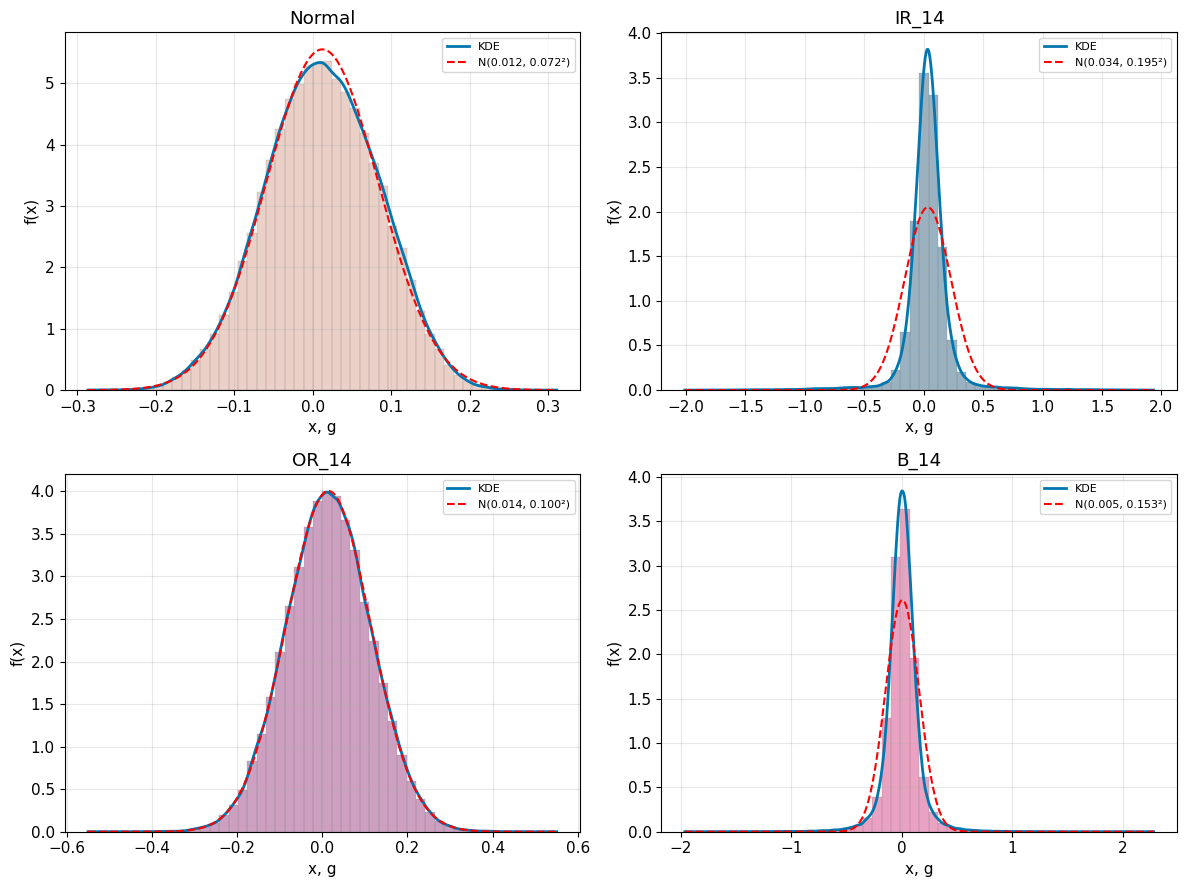

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for idx, name in enumerate(classes):
    ax = axes[idx // 2, idx % 2]
    signal = data[name]
    # KDE: f̂(x) = (1/nh) Σ K((x - xᵢ)/h)
    kde = gaussian_kde(signal)
    x_grid = np.linspace(signal.min(), signal.max(), 500)
    # Гистограмма
    ax.hist(signal, bins=50, density=True, color=COLORS[name],
            alpha=0.5, edgecolor='gray', linewidth=0.3)
    # KDE
    ax.plot(x_grid, kde(x_grid), color='#0176AF', lw=2, label='KDE')
    # Теоретическая нормальная кривая
    mu, sigma = np.mean(signal), np.std(signal)
    normal_pdf = stats.norm.pdf(x_grid, mu, sigma)
    ax.plot(x_grid, normal_pdf, 'r--', lw=1.5, label=f'N({mu:.3f}, {sigma:.3f}²)')

    ax.set_title(name)
    ax.set_xlabel('x, g')
    ax.set_ylabel('f(x)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [46]:
print("Таблица 2.4 — Результаты проверки статистических гипотез")

hypotheses = []

jb = jarque_bera_test(data['Normal']) # H1: Нормальность Normal (Харке-Бера)
hypotheses.append({
    '№': 1, 'Гипотеза': 'Нормальность Normal', 'Критерий': 'Харке-Бера',
    'Статистика': f"JB={jb['JB']:.0f}", 'p-value': f"{jb['p-value']:.2e}",
    'α': 0.05, 'Решение': 'H₀ отв.' if jb['p-value'] < 0.05 else 'H₀ прин.'
})

mw = mann_whitney_test(data['Normal'], data['IR_14']) # H2: F_Normal = F_IR (Манна-Уитни)
hypotheses.append({
    '№': 2, 'Гипотеза': 'F_Normal = F_IR', 'Критерий': 'Манна-Уитни',
    'Статистика': f"Z={mw['Z']:.0f}", 'p-value': f"{mw['p-value']:.2e}",
    'α': 0.05, 'Решение': 'H₀ отв.'
})

mw = mann_whitney_test(data['Normal'], data['OR_14']) # H3: F_Normal = F_OR (Манна-Уитни)
hypotheses.append({
    '№': 3, 'Гипотеза': 'F_Normal = F_OR', 'Критерий': 'Манна-Уитни',
    'Статистика': f"Z={mw['Z']:.0f}", 'p-value': f"{mw['p-value']:.2e}",
    'α': 0.05, 'Решение': 'H₀ отв.'
})

lrt = likelihood_ratio_test_var(data['Normal'], data['IR_14']) # H4: σ²_Normal = σ²_IR (LRT)
hypotheses.append({
    '№': 4, 'Гипотеза': 'σ²_Normal = σ²_IR', 'Критерий': 'LRT',
    'Статистика': f"Λ={lrt['Λ']:.0f}", 'p-value': f"{lrt['p-value']:.2e}",
    'α': 0.05, 'Решение': 'H₀ отв.'
})

mw = mann_whitney_test(data['Normal'], data['B_14']) # H5: Me_Normal = Me_B (Манна-Уитни)
hypotheses.append({
    '№': 5, 'Гипотеза': 'Me_Normal = Me_B', 'Критерий': 'Манна-Уитни',
    'Статистика': f"Z={mw['Z']:.0f}", 'p-value': f"{mw['p-value']:.2e}",
    'α': 0.05, 'Решение': 'H₀ отв.'
})

df_hyp = pd.DataFrame(hypotheses)
print(df_hyp.to_string(index=False))

Таблица 2.4 — Результаты проверки статистических гипотез
 №            Гипотеза    Критерий Статистика  p-value    α Решение
 1 Нормальность Normal  Харке-Бера     JB=274 0.00e+00 0.05 H₀ отв.
 2     F_Normal = F_IR Манна-Уитни      Z=-57 0.00e+00 0.05 H₀ отв.
 3     F_Normal = F_OR Манна-Уитни       Z=-5 1.28e-07 0.05 H₀ отв.
 4   σ²_Normal = σ²_IR         LRT   Λ=105183 0.00e+00 0.05 H₀ отв.
 5    Me_Normal = Me_B Манна-Уитни       Z=20 2.77e-93 0.05 H₀ отв.


# РАЗДЕЛ 3: ИДЕНТИФИКАЦИЯ РАСПРЕДЕЛЕНИЙ

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm, t as t_dist

classes = ['Normal', 'IR_14', 'OR_14', 'B_14']

def sturges_k(n):
    return int(1 + 3.322 * np.log10(n))

Критерий Пирсона — Нормальное распределение
Normal: χ² = 371, df = 14, χ²/n = 0.0030
IR_14: χ² = 45173, df = 5, χ²/n = 0.3707
OR_14: χ² = 11, df = 10, χ²/n = 0.0001
B_14: χ² = 12646, df = 3, χ²/n = 0.1038


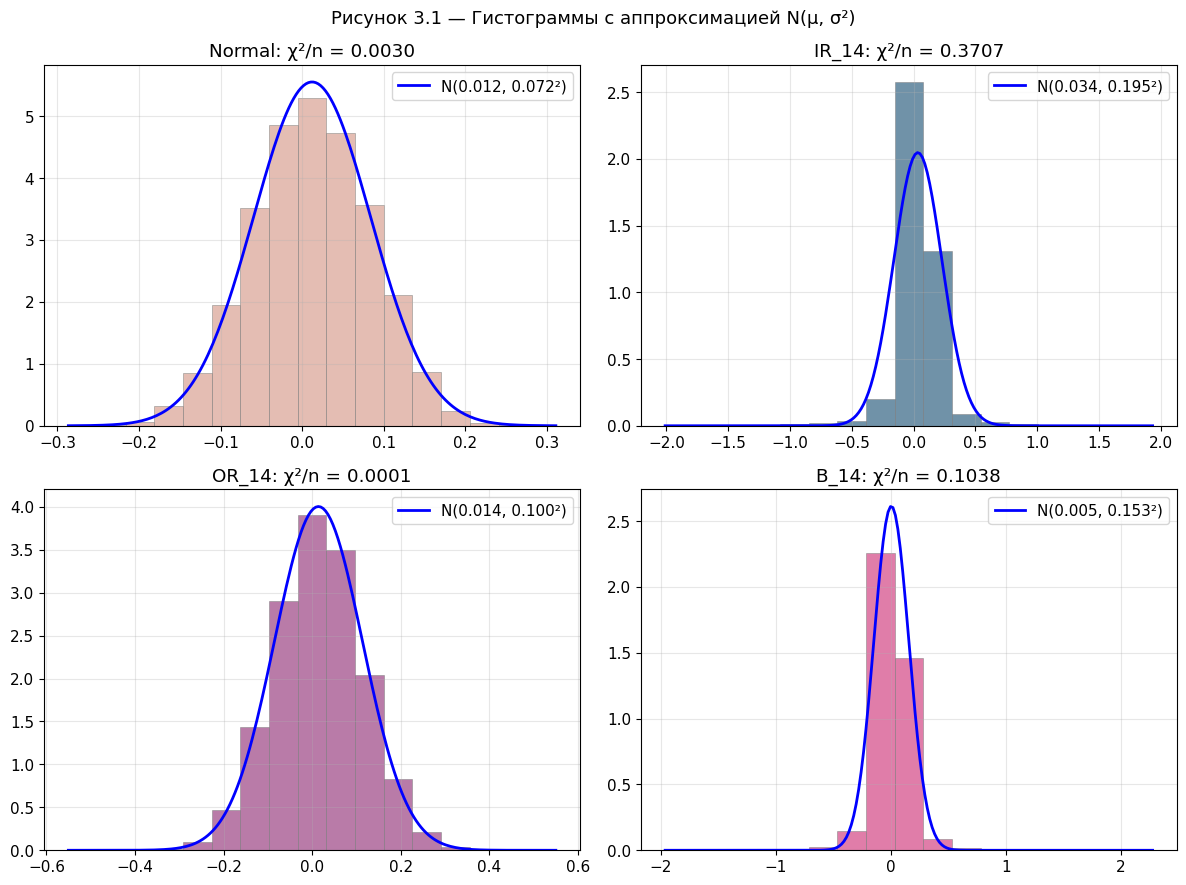

In [50]:
def pearson_normal(signal):
    """Критерий Пирсона для нормального распределения"""
    n = len(signal)
    k = sturges_k(n)
    # несмещённые точечные оценки параметров
    mu = np.mean(signal)
    sigma = np.std(signal, ddof=1)
    # наблюдаемые частоты
    observed, edges = np.histogram(signal, bins=k)
    # теоретические частоты: eᵢ = n·[Φ((aᵢ-μ)/σ) - Φ((aᵢ₋₁-μ)/σ)]
    expected = np.zeros(k)
    for i in range(k):
        p_i = norm.cdf(edges[i+1], mu, sigma) - norm.cdf(edges[i], mu, sigma)
        expected[i] = n * p_i
    # статистика χ² = Σ(nᵢ - eᵢ)²/eᵢ
    # объединяем интервалы с eᵢ < 5
    mask = expected >= 5
    obs_merged = observed[mask]
    exp_merged = expected[mask]
    chi2 = np.sum((obs_merged - exp_merged)**2 / exp_merged)
    # степени свободы: df = k - r - 1, где r = 2 (μ и σ)
    df = len(obs_merged) - 3
    p_value = 1 - stats.chi2.cdf(chi2, df)

    return {'chi2': chi2, 'df': df, 'chi2_n': chi2/n, 'p_value': p_value,
            'mu': mu, 'sigma': sigma}

print("Критерий Пирсона — Нормальное распределение")
results_norm = []
for name in classes:
    res = pearson_normal(data[name])
    results_norm.append({
        'Класс': name, 'χ²': res['chi2'], 'df': res['df'],
        'χ²/n': res['chi2_n'], 'p-value': res['p_value']
    })
    print(f"{name}: χ² = {res['chi2']:.0f}, df = {res['df']}, χ²/n = {res['chi2_n']:.4f}")

# гистограммы с нормальной аппроксимацией
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Рисунок 3.1 — Гистограммы с аппроксимацией N(μ, σ²)', fontsize=13)

for idx, name in enumerate(classes):
    ax = axes[idx // 2, idx % 2]
    signal = data[name]
    mu, sigma = np.mean(signal), np.std(signal, ddof=1)
    ax.hist(signal, bins=sturges_k(len(signal)), density=True,
            color=COLORS[name], alpha=0.7, edgecolor='gray', lw=0.5)

    x = np.linspace(signal.min(), signal.max(), 200)
    ax.plot(x, norm.pdf(x, mu, sigma), 'b-', lw=2, label=f'N({mu:.3f}, {sigma:.3f}²)')
    ax.set_title(f'{name}: χ²/n = {results_norm[idx]["χ²/n"]:.4f}')
    ax.legend()

plt.tight_layout()
plt.show()

Критерий Пирсона — t-распределение Стьюдента
Normal: ν = 30.0, χ² = 826, χ²/n = 0.0068
IR_14: ν = 5.0, χ² = 17547, χ²/n = 0.1440
OR_14: ν = 30.0, χ² = 137, χ²/n = 0.0011
B_14: ν = 5.0, χ² = 2131, χ²/n = 0.0175


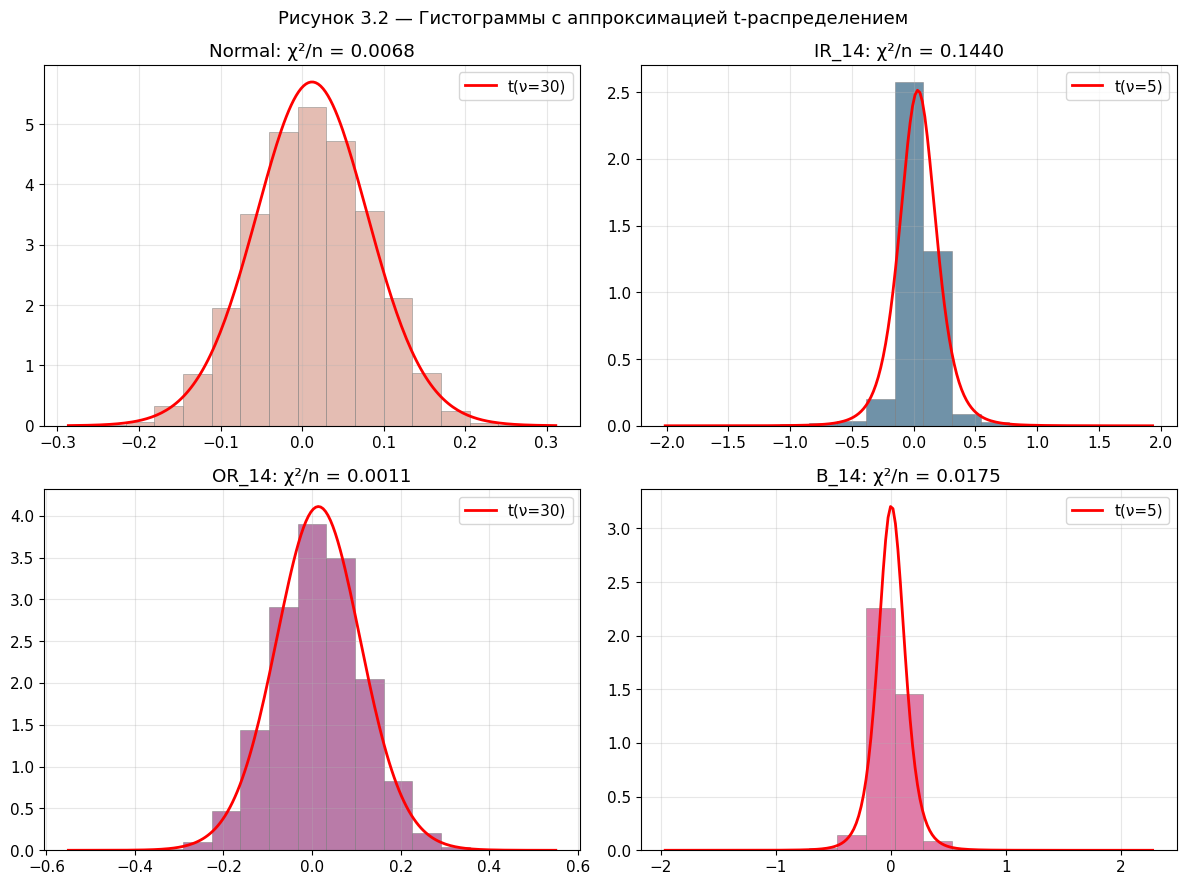

In [52]:
def pearson_t(signal):
    """Критерий Пирсона для t-распределения Стьюдента"""
    n = len(signal)
    k = sturges_k(n)
    # оценка параметров
    mu = np.mean(signal)
    kurtosis = stats.kurtosis(signal)  # эксцесс
    # степени свободы: ν = 4 + 6/γ₂ (если γ₂ > 0)
    if kurtosis > 0.1:
        nu = max(5, 4 + 6 / kurtosis)
    else:
        nu = 30  # приближение к нормальному
    # масштаб: σ = S·√((ν-2)/ν)
    S = np.std(signal, ddof=1)
    sigma = S * np.sqrt((nu - 2) / nu) if nu > 2 else S
    # наблюдаемые частоты
    observed, edges = np.histogram(signal, bins=k)
    # теоретические частоты для t-распределения
    expected = np.zeros(k)
    for i in range(k):
        z1 = (edges[i] - mu) / sigma
        z2 = (edges[i+1] - mu) / sigma
        p_i = t_dist.cdf(z2, nu) - t_dist.cdf(z1, nu)
        expected[i] = n * p_i
    # статистика χ²
    mask = expected >= 5
    obs_merged = observed[mask]
    exp_merged = expected[mask]
    chi2 = np.sum((obs_merged - exp_merged)**2 / exp_merged)
    # df = k - r - 1, где r = 3 (ν, μ, σ)
    df = len(obs_merged) - 4
    p_value = 1 - stats.chi2.cdf(chi2, max(1, df))

    return {'chi2': chi2, 'df': df, 'chi2_n': chi2/n, 'p_value': p_value,
            'nu': nu, 'mu': mu, 'sigma': sigma}

print("Критерий Пирсона — t-распределение Стьюдента")
results_t = []
for name in classes:
    res = pearson_t(data[name])
    results_t.append({
        'Класс': name, 'ν': res['nu'], 'χ²': res['chi2'],
        'df': res['df'], 'χ²/n': res['chi2_n']
    })
    print(f"{name}: ν = {res['nu']:.1f}, χ² = {res['chi2']:.0f}, χ²/n = {res['chi2_n']:.4f}")

# гистограммы с t-аппроксимацией
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Рисунок 3.2 — Гистограммы с аппроксимацией t-распределением', fontsize=13)

for idx, name in enumerate(classes):
    ax = axes[idx // 2, idx % 2]
    signal = data[name]
    res = pearson_t(signal)

    ax.hist(signal, bins=sturges_k(len(signal)), density=True,
            color=COLORS[name], alpha=0.7, edgecolor='gray', lw=0.5)

    x = np.linspace(signal.min(), signal.max(), 200)
    # плотность t-распределения со сдвигом и масштабом
    pdf_t = t_dist.pdf((x - res['mu']) / res['sigma'], res['nu']) / res['sigma']
    ax.plot(x, pdf_t, 'r-', lw=2, label=f't(ν={res["nu"]:.0f})')
    ax.set_title(f'{name}: χ²/n = {res["chi2_n"]:.4f}')
    ax.legend()

plt.tight_layout()
plt.show()

Метод анаморфоз
Класс    Распр.             R²          a          b         μ̂         σ̂
Normal   Норм.          0.9992      13.92     -0.171     0.0123     0.0719
Normal   t-Стьюд.       0.9969      14.46     -0.178     0.0123     0.0692
IR_14    Норм.          0.7458       4.18     -0.139     0.0333     0.2392
IR_14    t-Стьюд.       0.9053       6.61     -0.237     0.0359     0.1513
OR_14    Норм.          0.9966       9.90     -0.140     0.0141     0.1010
OR_14    t-Стьюд.       0.9987      10.30     -0.147     0.0142     0.0971
B_14     Норм.          0.8057       5.31     -0.015     0.0029     0.1882
B_14     t-Стьюд.       0.9772       8.40     -0.041     0.0049     0.1191


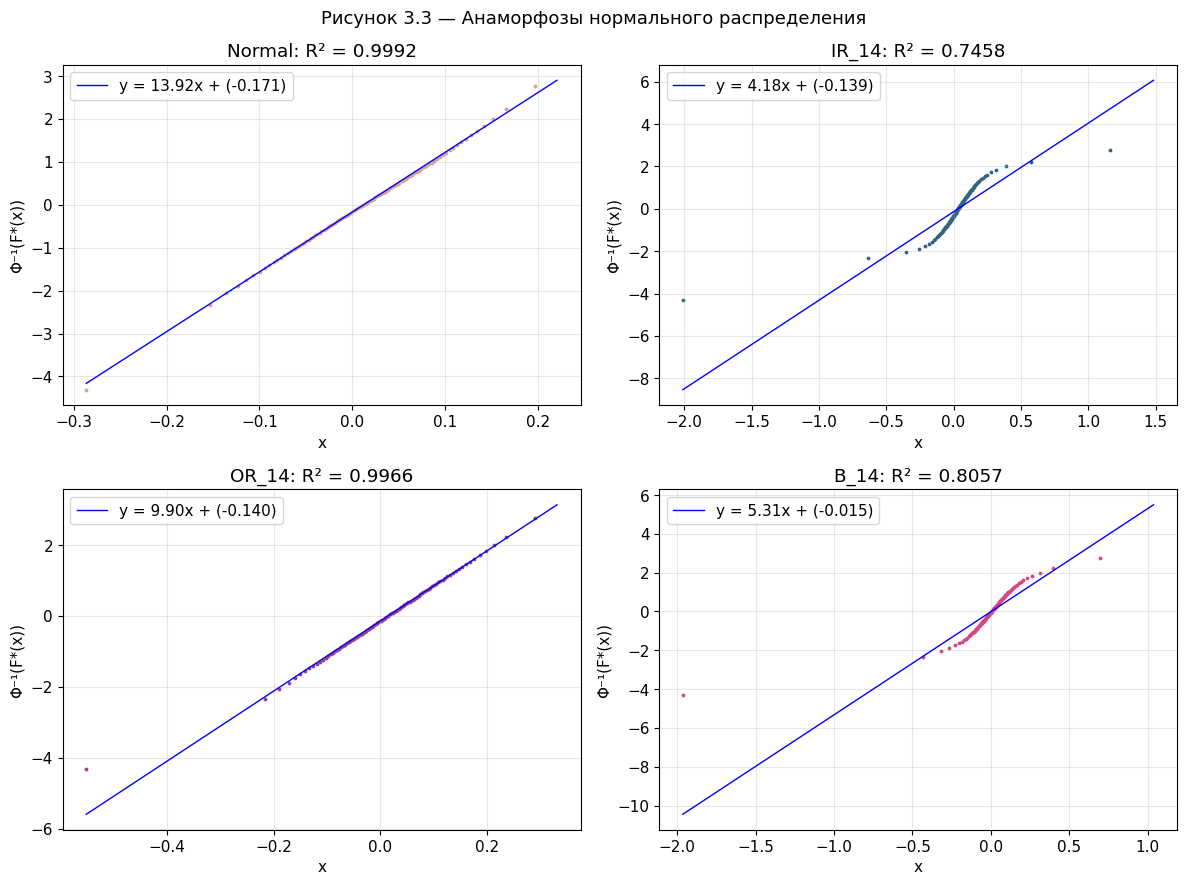

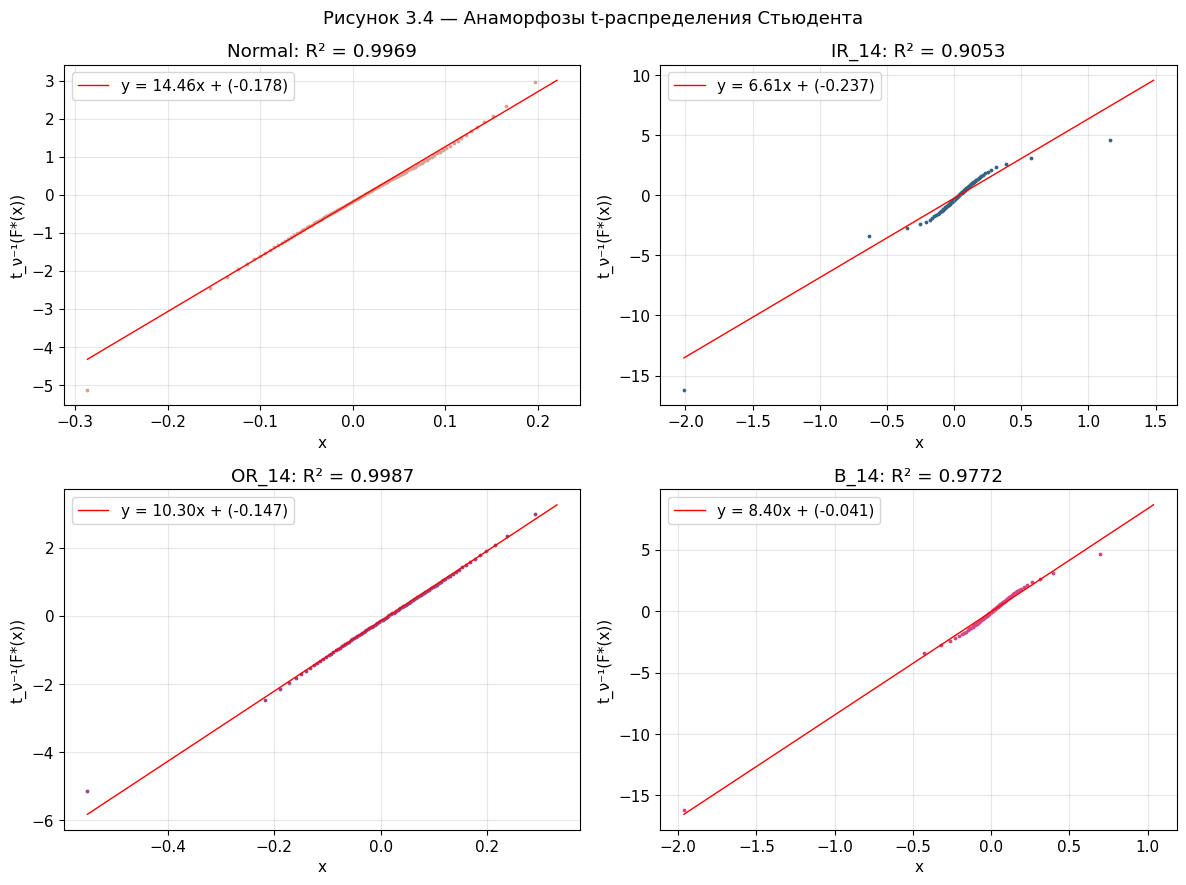

In [53]:
def anamorphosis(signal, dist='normal'):
    """
    Анаморфоза: y = F⁻¹(F*(x))
    Возвращает: R², угловой коэфф., своб. член, параметры
    """
    n = len(signal)
    sorted_signal = np.sort(signal)
    # эмпирическая функция распределения F*(x) = i/(n+1)
    F_emp = np.arange(1, n + 1) / (n + 1)
    # прореживание для визуализации и регрессии
    step = max(1, n // 500)
    x = sorted_signal[::step]
    F = F_emp[::step]
    # анаморфоза: y = F⁻¹(F*(x))
    if dist == 'normal':
        y = norm.ppf(F)  # Φ⁻¹(F*)
    else:  # t-распределение
        kurtosis = stats.kurtosis(signal)
        nu = max(5, 4 + 6 / kurtosis) if kurtosis > 0.1 else 30
        y = t_dist.ppf(F, nu)  # t_ν⁻¹(F*)
    # линейная регрессия: y = ax + b
    mask = np.isfinite(y)
    x_fit, y_fit = x[mask], y[mask]
    slope, intercept, r_value, _, _ = stats.linregress(x_fit, y_fit)
    R2 = r_value**2
    # параметры распределения: σ = 1/a, μ = -b/a
    sigma_est = 1 / slope if slope != 0 else np.nan
    mu_est = -intercept / slope if slope != 0 else np.nan

    return {
        'R2': R2, 'a': slope, 'b': intercept,
        'mu': mu_est, 'sigma': sigma_est,
        'x': x_fit, 'y': y_fit
    }

# расчёт анаморфоз для всех классов и обоих распределений
print("Метод анаморфоз")
print(f"{'Класс':<8} {'Распр.':<12} {'R²':>8} {'a':>10} {'b':>10} {'μ̂':>10} {'σ̂':>10}")

results_anam = []
for name in classes:
    for dist in ['normal', 't']:
        res = anamorphosis(data[name], dist)
        dist_name = 'Норм.' if dist == 'normal' else 't-Стьюд.'
        print(f"{name:<8} {dist_name:<12} {res['R2']:>8.4f} {res['a']:>10.2f} "
              f"{res['b']:>10.3f} {res['mu']:>10.4f} {res['sigma']:>10.4f}")
        results_anam.append({
            'Класс': name, 'Распределение': dist_name,
            'R²': res['R2'], 'a': res['a'], 'b': res['b'],
            'μ̂': res['mu'], 'σ̂': res['sigma']
        })

# графики анаморфоз — нормальное распределение
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Рисунок 3.3 — Анаморфозы нормального распределения', fontsize=13)

for idx, name in enumerate(classes):
    ax = axes[idx // 2, idx % 2]
    res = anamorphosis(data[name], 'normal')
    ax.scatter(res['x'][::5], res['y'][::5], s=3, alpha=1.0, color=COLORS[name])
    # линия регрессии
    x_line = np.array([res['x'].min(), res['x'].max()])
    y_line = res['a'] * x_line + res['b']
    ax.plot(x_line, y_line, 'b-', lw=1, label=f'y = {res["a"]:.2f}x + ({res["b"]:.3f})')
    ax.set_xlabel('x')
    ax.set_ylabel('Φ⁻¹(F*(x))')
    ax.set_title(f'{name}: R² = {res["R2"]:.4f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# графики анаморфоз — t-распределение
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Рисунок 3.4 — Анаморфозы t-распределения Стьюдента', fontsize=13)

for idx, name in enumerate(classes):
    ax = axes[idx // 2, idx % 2]
    res = anamorphosis(data[name], 't')
    ax.scatter(res['x'][::5], res['y'][::5], s=3, alpha=1.0, color=COLORS[name])
    x_line = np.array([res['x'].min(), res['x'].max()])
    y_line = res['a'] * x_line + res['b']
    ax.plot(x_line, y_line, 'r-', lw=1, label=f'y = {res["a"]:.2f}x + ({res["b"]:.3f})')
    ax.set_xlabel('x')
    ax.set_ylabel('t_ν⁻¹(F*(x))')
    ax.set_title(f'{name}: R² = {res["R2"]:.4f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [54]:
print("Таблица 3.3 — Сравнение методов идентификации распределений")

comparison = []
for name in classes:
    # Пирсон
    chi2_norm = next(r['χ²/n'] for r in results_norm if r['Класс'] == name)
    chi2_t = next(r['χ²/n'] for r in results_t if r['Класс'] == name)
    best_pearson = 'Норм.' if chi2_norm < chi2_t else 't-Стьюд.'
    best_chi2 = min(chi2_norm, chi2_t)

    # анаморфозы
    r2_norm = next(r['R²'] for r in results_anam if r['Класс']==name and r['Распределение']=='Норм.')
    r2_t = next(r['R²'] for r in results_anam if r['Класс']==name and r['Распределение']=='t-Стьюд.')
    best_anam = 'Норм.' if r2_norm > r2_t else 't-Стьюд.'
    best_r2 = max(r2_norm, r2_t)

    # согласованность
    consistent = 'Да' if best_pearson == best_anam else 'Нет'
    comparison.append({
        'Класс': name,
        'Пирсон (лучшее)': best_pearson, 'χ²/n': best_chi2,
        'Анаморфозы (лучшее)': best_anam, 'R²': best_r2,
        'Согласов.': consistent
    })

df_comp = pd.DataFrame(comparison)
print(df_comp.to_string(index=False))

Таблица 3.3 — Сравнение методов идентификации распределений
 Класс Пирсон (лучшее)     χ²/n Анаморфозы (лучшее)       R² Согласов.
Normal           Норм. 0.003049               Норм. 0.999242        Да
 IR_14        t-Стьюд. 0.144006            t-Стьюд. 0.905274        Да
 OR_14           Норм. 0.000089            t-Стьюд. 0.998731       Нет
  B_14        t-Стьюд. 0.017487            t-Стьюд. 0.977216        Да


# Заключение
Статистические методы позволяют объективно диагностировать техническое состояние подшипников качения. Ключевыми диагностическими
признаками являются:
+ среднеквадратическое отклонение — превышение нормы в 2–3 раза
указывает на наличие дефекта;
+ коэффициент эксцесса — значения γ₂ > 10 характерны для дефектов
внутренней обоймы и тела качения;
+ форма распределения — отклонение от нормальности в сторону
лептокуртичности (t-распределение) свидетельствует о наличии
ударных импульсов, генерируемых дефектами.